In [9]:
# 1. Random walk: simular una caminata aleatoria en 1D y 2D (N pasos). Estimar E[|XN|] y E[(X**2)N] por Monte Carlo. Comparar con los valores teóricos (∼√N, = N)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

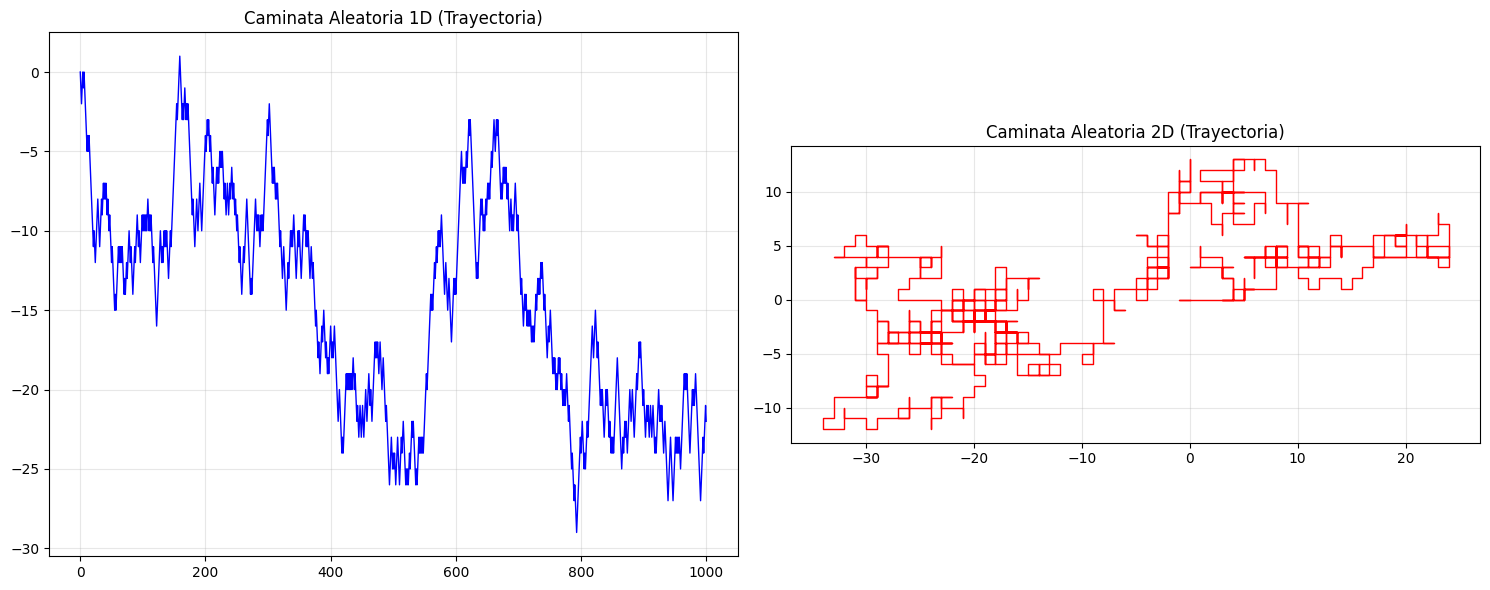

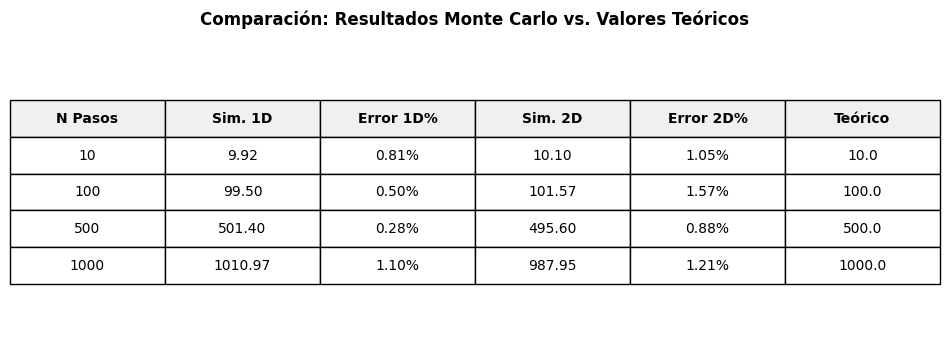

In [ ]:
# --- 1. DEFINICIÓN DE FUNCIONES PARA CAMINATAS ALEATORIAS
# Generan los movimientos necesarios para los gráficos de trayectorias

def simular_rw_1d(n):
    rng = np.random.default_rng()
    pasos = rng.choice([-1, 1], size=n)
    trayectoria = np.cumsum(np.insert(pasos, 0, 0))
    return pasos, trayectoria

def simular_rw_2d(n): 
    # Generamos números del 0 al 3 para representar las 4 direcciones (N, S, E, O)
    rng = np.random.default_rng()
    pasos = rng.integers(0, 4, size=n)
    dx = np.where(pasos == 2, 1, np.where(pasos == 3, -1, 0))
    dy = np.where(pasos == 0, 1, np.where(pasos == 1, -1, 0))
    tray_x = np.cumsum(np.insert(dx, 0, 0))
    tray_y = np.cumsum(np.insert(dy, 0, 0))
    return pasos, (tray_x, tray_y)

# --- 2. SIMULACIÓN DE MONTE CARLO
# Comparamos los resultados simulados contra el valor teórico N.

def analizar_teoria_rw(pasos_lista, n_sims=5000):
    rng = np.random.default_rng(42)
    resultados = []
    
    for n in pasos_lista:
        # Simulación 1D: Calculamos el promedio de las posiciones finales al cuadrado
        pasos_1d = rng.choice([-1, 1], size=(n_sims, n))
        pos_final_1d = np.sum(pasos_1d, axis=1)
        sim_1d = np.mean(pos_final_1d**2)
        
        # Simulación 2D: Calculamos el promedio del radio al cuadrado (x**2 + y**2)
        pasos_2d = rng.integers(0, 4, size=(n_sims, n))
        dx = np.where(pasos_2d == 2, 1, np.where(pasos_2d == 3, -1, 0))
        dy = np.where(pasos_2d == 0, 1, np.where(pasos_2d == 1, -1, 0))
        xf, yf = np.sum(dx, axis=1), np.sum(dy, axis=1)
        sim_2d = np.mean(xf**2 + yf**2)
        
        # Cálculo de errores para ver qué tan precisa fue la simulación
        teorico = float(n)
        err_1d = abs(sim_1d - teorico) / teorico * 100
        err_2d = abs(sim_2d - teorico) / teorico * 100
        
        resultados.append([n, sim_1d, err_1d, sim_2d, err_2d, teorico])
        
    return resultados

# --- 3. EJECUCIÓN DE LAS PRUEBAS
pasos_test = [10, 100, 500, 1000]
datos = analizar_teoria_rw(pasos_test)

# --- 4. VISUALIZACIÓN DE TRAYECTORIAS Y GUARDADO 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1D
_, tray_1d = simular_rw_1d(1000)
ax1.plot(tray_1d, color='blue', lw=1)
ax1.set_title("Caminata Aleatoria 1D (Trayectoria)")
ax1.grid(alpha=0.3)

# Gráfico 2D
_, (tray_2dx, tray_2dy) = simular_rw_2d(1000)
ax2.plot(tray_2dx, tray_2dy, color='red', lw=1)
ax2.set_title("Caminata Aleatoria 2D (Trayectoria)")
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figs/graficos_trayectorias_rw.png", bbox_inches='tight', dpi=300)
plt.show()

# --- 5. GENERACIÓN DE LA TABLA
columnas = ["N Pasos", "Sim. 1D", "Error 1D%", "Sim. 2D", "Error 2D%", "Teórico"]
celdas = [[str(r[0]), f"{r[1]:.2f}", f"{r[2]:.2f}%", f"{r[3]:.2f}", f"{r[4]:.2f}%", f"{r[5]}"] for r in datos]

fig_tab, ax_tab = plt.subplots(figsize=(10, 4))
ax_tab.axis('off')
ax_tab.axis('tight')

# Crear la tabla
tabla = ax_tab.table(cellText=celdas, colLabels=columnas, loc='center', cellLoc='center')

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2.2)

# Estética del encabezado (Negrita y fondo gris)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f0f0f0')

plt.title("Comparación: Resultados Monte Carlo vs. Valores Teóricos", fontsize=12, pad=10, fontweight='bold')
plt.savefig("../figs/tabla_comparativa_rw.png", bbox_inches='tight', dpi=300)
plt.show()